In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('cumulative.csv')

In [3]:
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [4]:
df.shape

(9564, 50)

In [5]:
df.columns

Index(['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_disposition',
       'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss',
       'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1',
       'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1',
       'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2',
       'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth',
       'koi_depth_err1', 'koi_depth_err2', 'koi_prad', 'koi_prad_err1',
       'koi_prad_err2', 'koi_teq', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol',
       'koi_insol_err1', 'koi_insol_err2', 'koi_model_snr', 'koi_tce_plnt_num',
       'koi_tce_delivname', 'koi_steff', 'koi_steff_err1', 'koi_steff_err2',
       'koi_slogg', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad',
       'koi_srad_err1', 'koi_srad_err2', 'ra', 'dec', 'koi_kepmag'],
      dtype='str')

In [6]:
columns = list(df.columns)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   str    
 3   kepler_name        2294 non-null   str    
 4   koi_disposition    9564 non-null   str    
 5   koi_pdisposition   9564 non-null   str    
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 non-null   

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rowid,9564.0,4.782500e+03,2.761033e+03,1.000000e+00,2.391750e+03,4.782500e+03,7.173250e+03,9.564000e+03
kepid,9564.0,7.690628e+06,2.653459e+06,7.574500e+05,5.556034e+06,7.906892e+06,9.873066e+06,1.293514e+07
koi_score,8054.0,4.808294e-01,4.769285e-01,0.000000e+00,0.000000e+00,3.340000e-01,9.980000e-01,1.000000e+00
koi_fpflag_nt,9564.0,1.882058e-01,3.908968e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
koi_fpflag_ss,9564.0,2.315977e-01,4.218753e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
koi_fpflag_co,9564.0,1.948975e-01,3.961425e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
koi_fpflag_ec,9564.0,1.200335e-01,3.250176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
koi_period,9564.0,7.567136e+01,1.334744e+03,2.418425e-01,2.733684e+00,9.752831e+00,4.071518e+01,1.299958e+05
koi_period_err1,9110.0,2.147864e-03,8.236369e-03,0.000000e+00,5.345750e-06,3.520500e-05,2.762000e-04,1.725000e-01
koi_period_err2,9110.0,-2.147864e-03,8.236369e-03,-1.725000e-01,-2.762000e-04,-3.520500e-05,-5.345750e-06,0.000000e+00


In [9]:
df["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

In [10]:
counts = df["koi_disposition"].value_counts()
total = len(df)
print(f"FALSE POSITIVE: {(counts['FALSE POSITIVE']/total)*100} %")
print(f"CONFIRMED: {(counts['CONFIRMED']/total)*100} %")
print(f"CANDIDATE: {(counts['CANDIDATE']/total)*100} %")

FALSE POSITIVE: 52.51986616478461 %
CONFIRMED: 23.975324132162275 %
CANDIDATE: 23.504809703053116 %


In [11]:
df["koi_disposition"].value_counts(normalize=True) * 100

koi_disposition
FALSE POSITIVE    52.519866
CONFIRMED         23.975324
CANDIDATE         23.504810
Name: proportion, dtype: float64

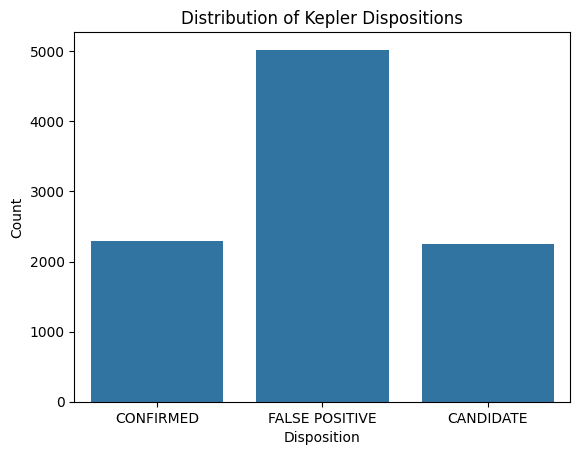

In [12]:
sns.countplot(x="koi_disposition", data=df)
plt.title("Distribution of Kepler Dispositions")
plt.xlabel("Disposition")
plt.ylabel("Count")
plt.show()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["kepid"].nunique()

8214

In [15]:
(df["kepid"].value_counts() > 1).sum()

np.int64(938)

In [16]:
df.isnull().sum()

rowid                   0
kepid                   0
kepoi_name              0
kepler_name          7270
koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff   

In [17]:
target_col = "koi_disposition"

transit_cols = [
    "koi_period",
    "koi_time0bk",
    "koi_impact",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_teq",
    "koi_insol",
    "koi_model_snr"
]

stellar_cols = [
    "koi_steff",
    "koi_slogg",
    "koi_srad"
]

flag_cols = [
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec"
]

coordinate_cols = [
    "ra",
    "dec",
    "koi_kepmag"
]

uncertainty_cols = [c for c in columns if "err" in c]

In [18]:
uncertainty_cols

['koi_period_err1',
 'koi_period_err2',
 'koi_time0bk_err1',
 'koi_time0bk_err2',
 'koi_impact_err1',
 'koi_impact_err2',
 'koi_duration_err1',
 'koi_duration_err2',
 'koi_depth_err1',
 'koi_depth_err2',
 'koi_prad_err1',
 'koi_prad_err2',
 'koi_teq_err1',
 'koi_teq_err2',
 'koi_insol_err1',
 'koi_insol_err2',
 'koi_steff_err1',
 'koi_steff_err2',
 'koi_slogg_err1',
 'koi_slogg_err2',
 'koi_srad_err1',
 'koi_srad_err2']

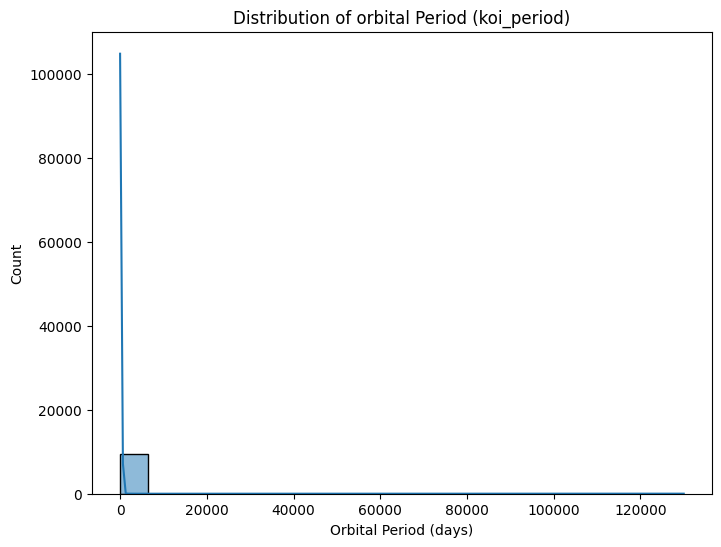

In [19]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_period"], bins=20, kde=True)
plt.title("Distribution of orbital Period (koi_period)")
plt.xlabel("Orbital Period (days)")
plt.ylabel("Count")
plt.show()

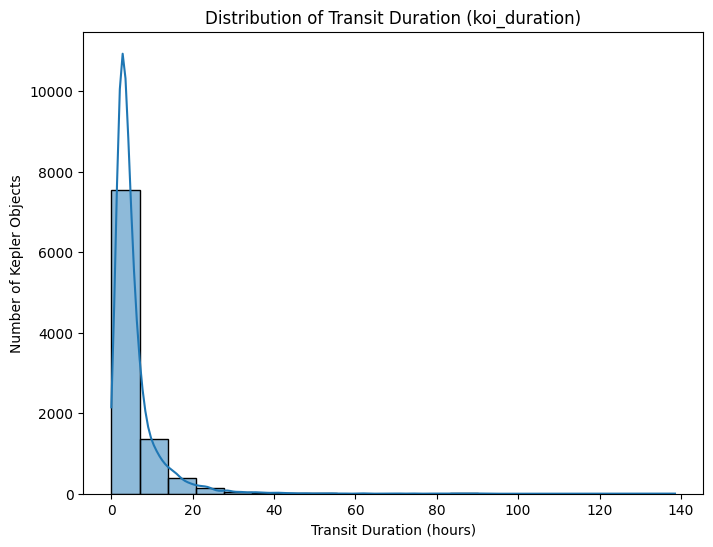

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_duration"], bins=20, kde=True)
plt.title("Distribution of Transit Duration (koi_duration)")
plt.xlabel("Transit Duration (hours)")
plt.ylabel("Number of Kepler Objects")
plt.show()

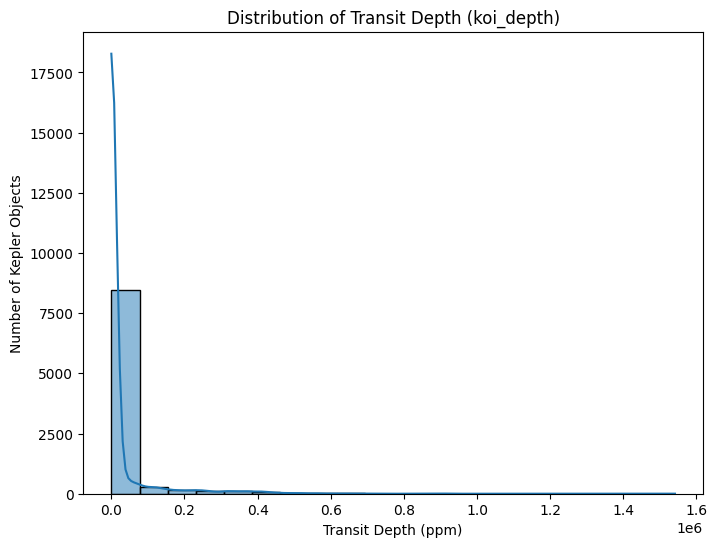

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_depth"], bins=20, kde=True)
plt.title("Distribution of Transit Depth (koi_depth)")
plt.xlabel("Transit Depth (ppm)")
plt.ylabel("Number of Kepler Objects")
plt.show()

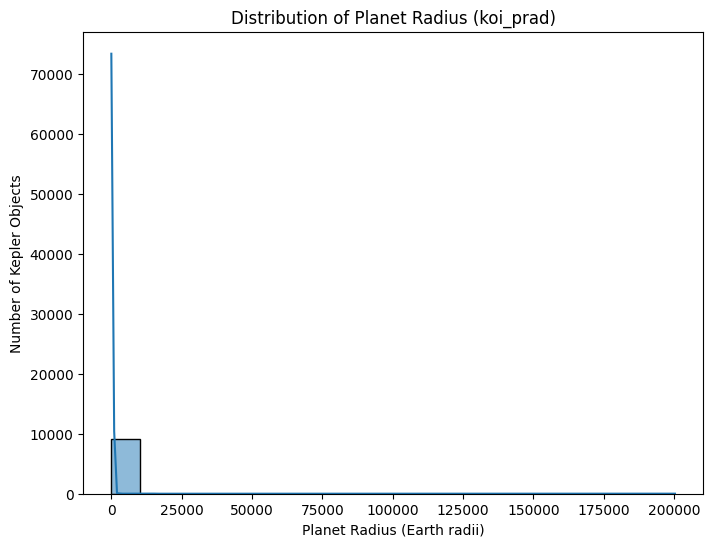

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_prad"], bins=20, kde=True)
plt.title("Distribution of Planet Radius (koi_prad)")
plt.xlabel("Planet Radius (Earth radii)")
plt.ylabel("Number of Kepler Objects")
plt.show()

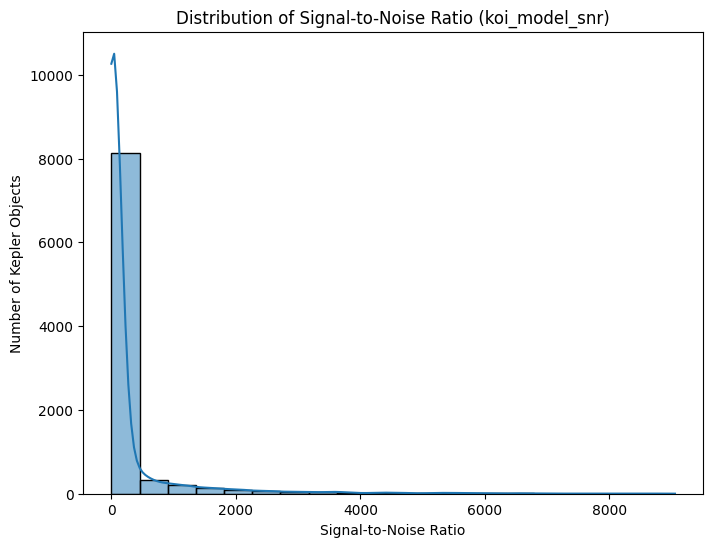

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_model_snr"], bins=20, kde=True)
plt.title("Distribution of Signal-to-Noise Ratio (koi_model_snr)")
plt.xlabel("Signal-to-Noise Ratio")
plt.ylabel("Number of Kepler Objects")
plt.show()

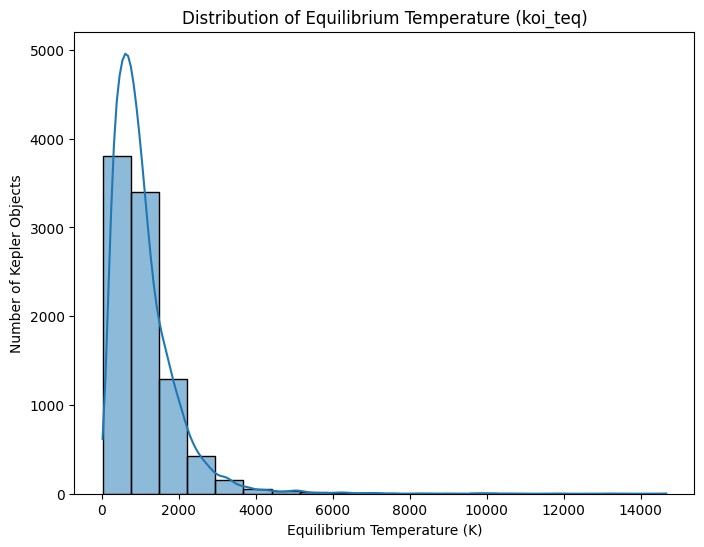

In [24]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_teq"], bins=20, kde=True)
plt.title("Distribution of Equilibrium Temperature (koi_teq)")
plt.xlabel("Equilibrium Temperature (K)")
plt.ylabel("Number of Kepler Objects")
plt.show()

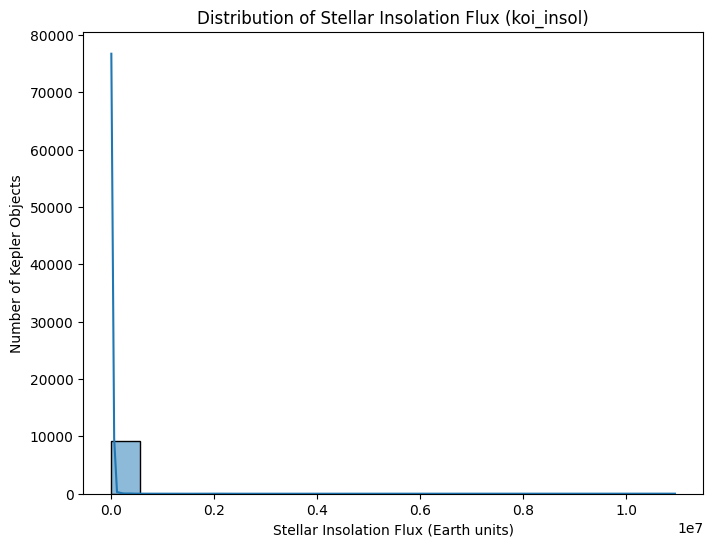

In [25]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_insol"], bins=20, kde=True)
plt.title("Distribution of Stellar Insolation Flux (koi_insol)")
plt.xlabel("Stellar Insolation Flux (Earth units)")
plt.ylabel("Number of Kepler Objects")
plt.show()

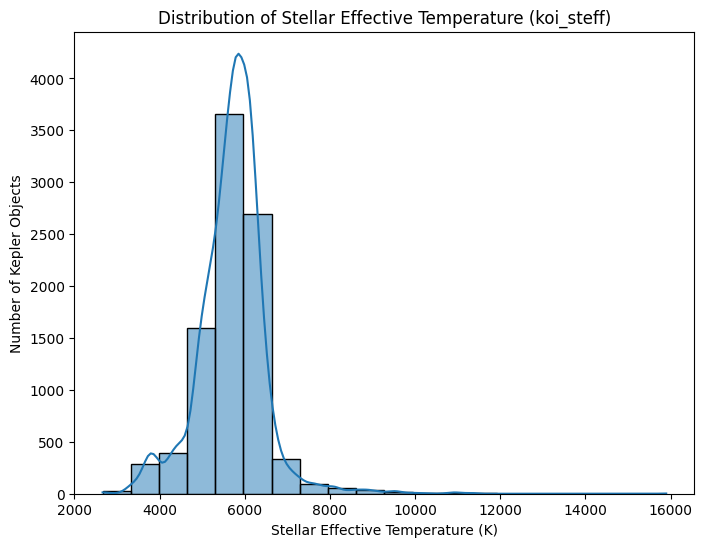

In [26]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_steff"], bins=20, kde=True)
plt.title("Distribution of Stellar Effective Temperature (koi_steff)")
plt.xlabel("Stellar Effective Temperature (K)")
plt.ylabel("Number of Kepler Objects")
plt.show()

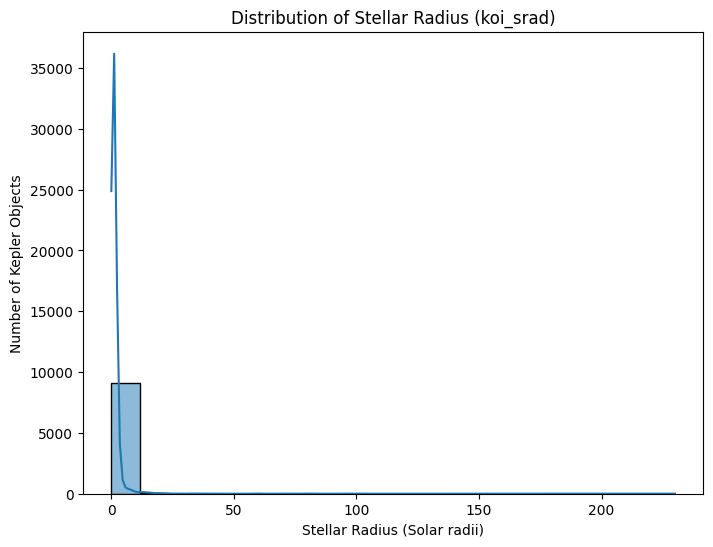

In [27]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_srad"], bins=20, kde=True)
plt.title("Distribution of Stellar Radius (koi_srad)")
plt.xlabel("Stellar Radius (Solar radii)")
plt.ylabel("Number of Kepler Objects")
plt.show()

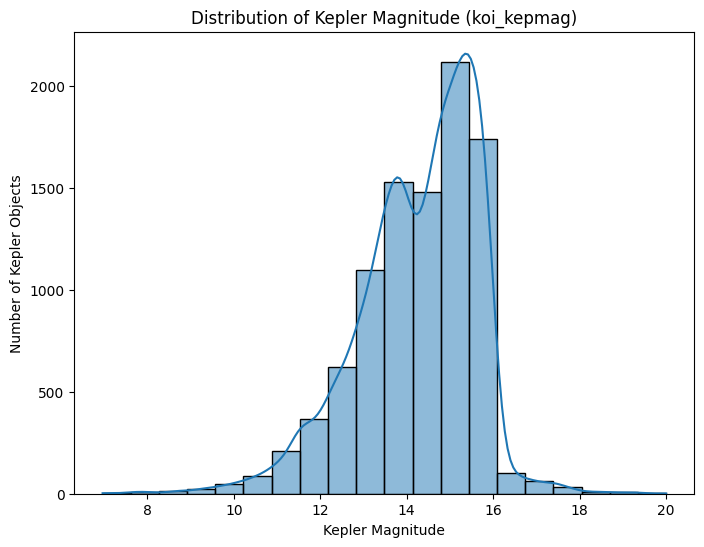

In [28]:
plt.figure(figsize=(8,6))
sns.histplot(df["koi_kepmag"], bins=20, kde=True)
plt.title("Distribution of Kepler Magnitude (koi_kepmag)")
plt.xlabel("Kepler Magnitude")
plt.ylabel("Number of Kepler Objects")
plt.show()

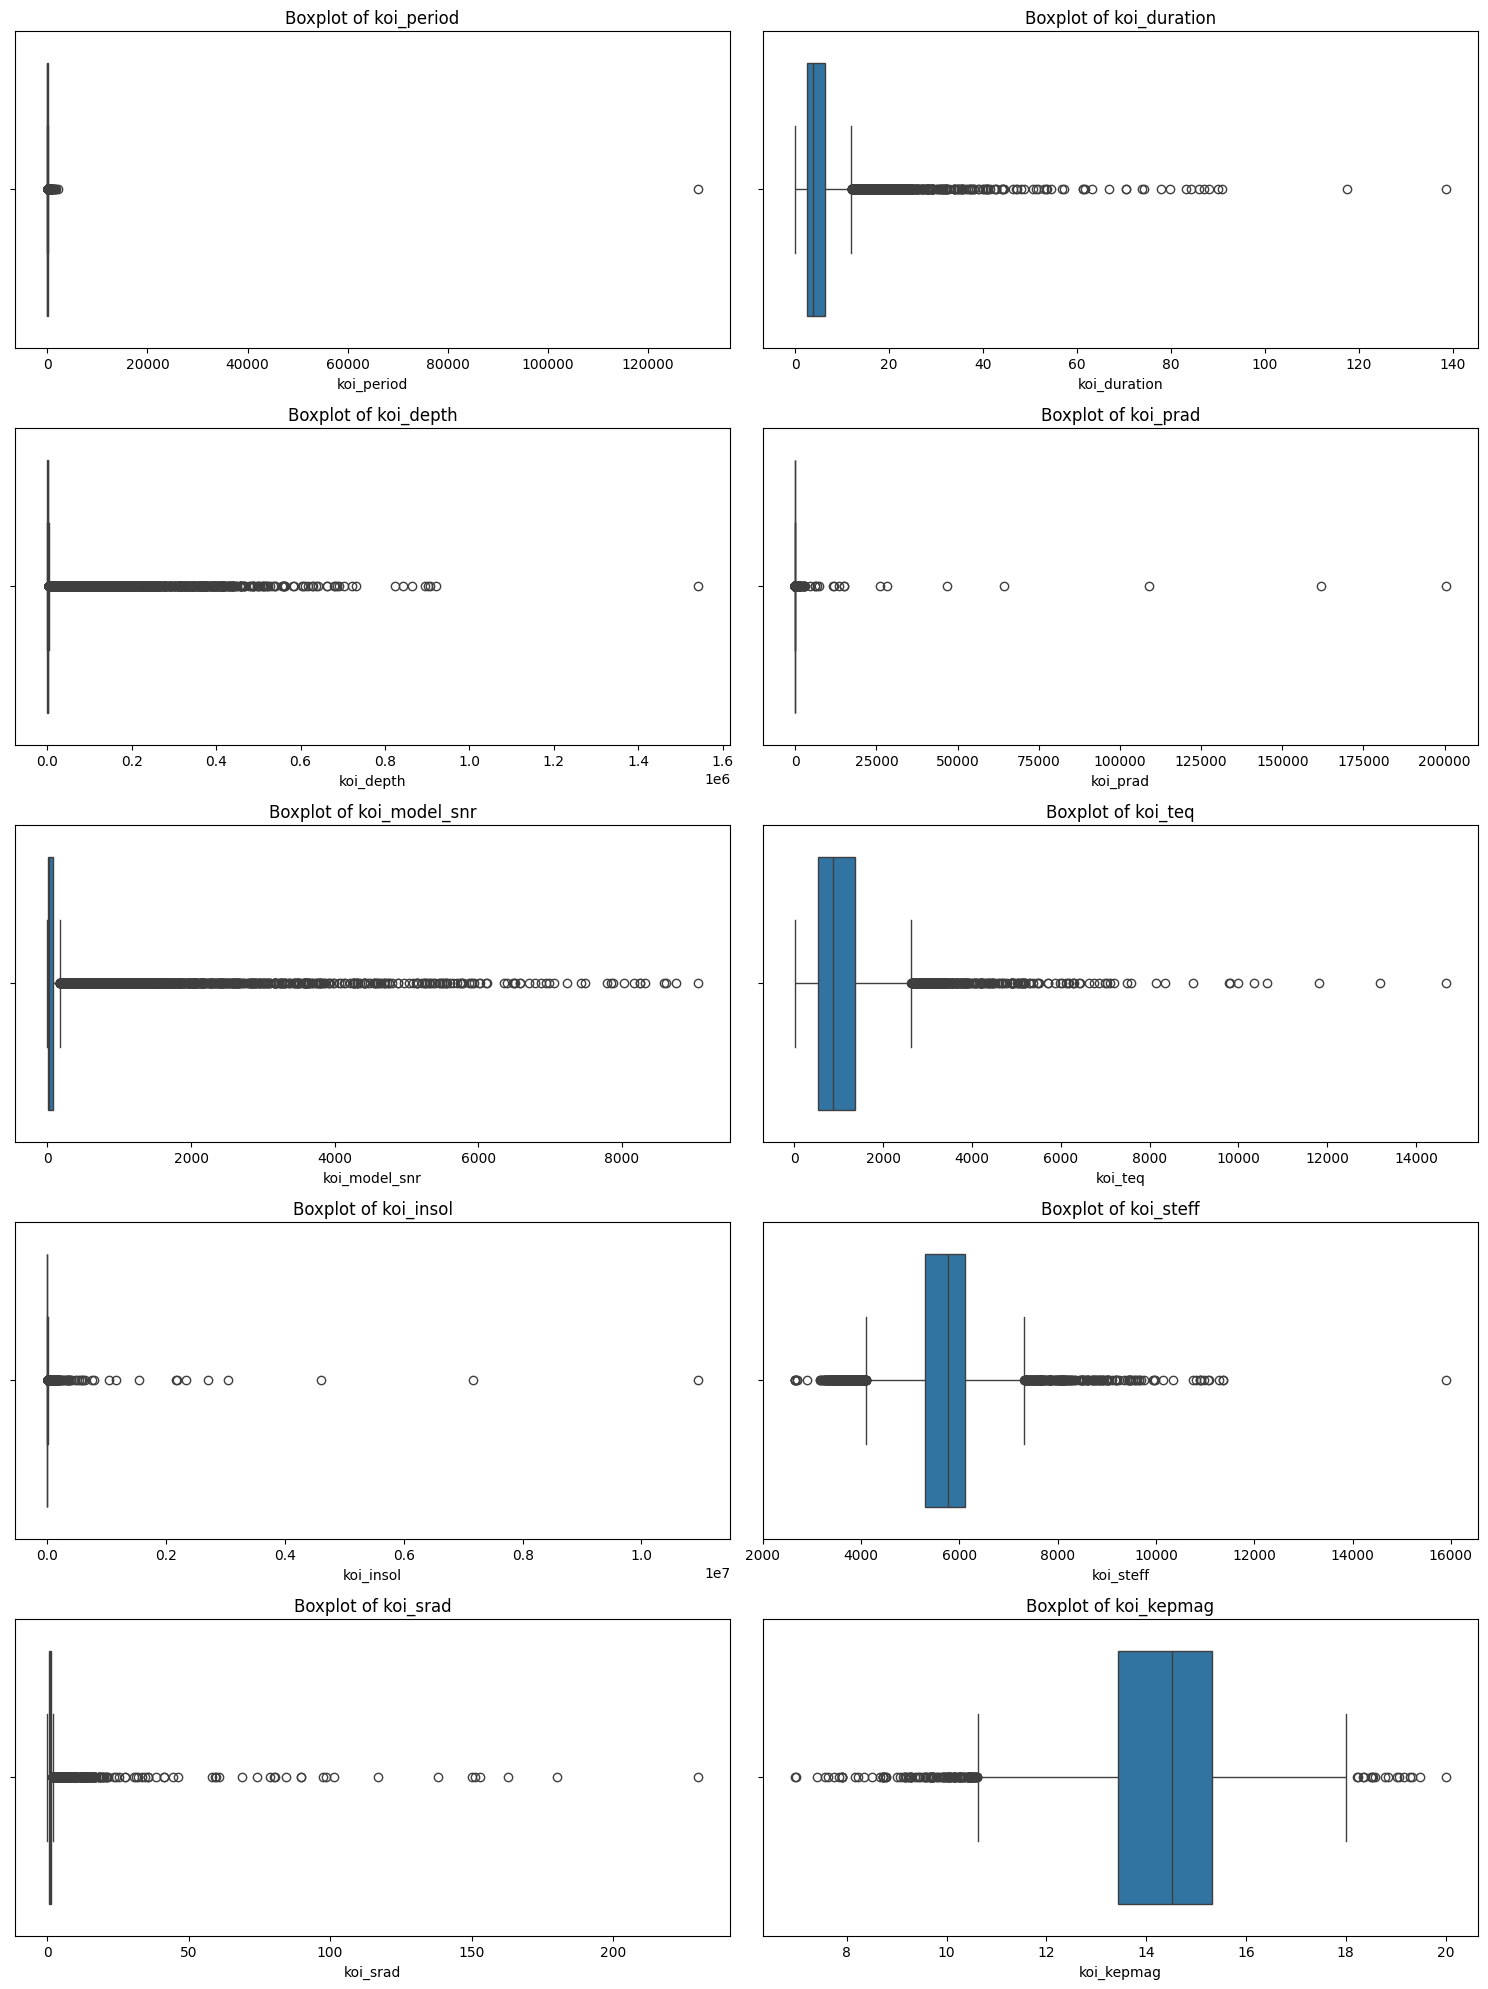

In [29]:
boxplot_features = [
    "koi_period", "koi_duration", "koi_depth", "koi_prad",
    "koi_model_snr", "koi_teq", "koi_insol",
    "koi_steff", "koi_srad", "koi_kepmag"
]

plt.figure(figsize=(15,20))

for i, feature in enumerate(boxplot_features, 1):
    plt.subplot(5,2,i)
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

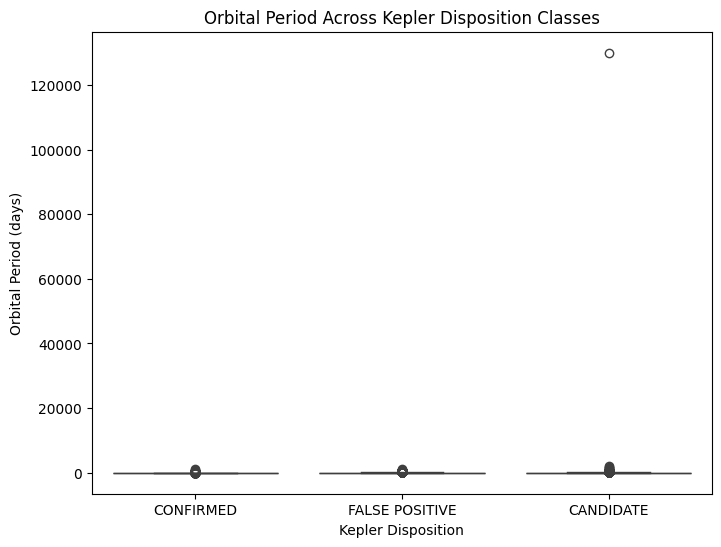

In [30]:
plt.figure(figsize=(8,6))
sns.boxplot(x="koi_disposition", y="koi_period", data=df)
plt.title("Orbital Period Across Kepler Disposition Classes")
plt.xlabel("Kepler Disposition")
plt.ylabel("Orbital Period (days)")
plt.show()

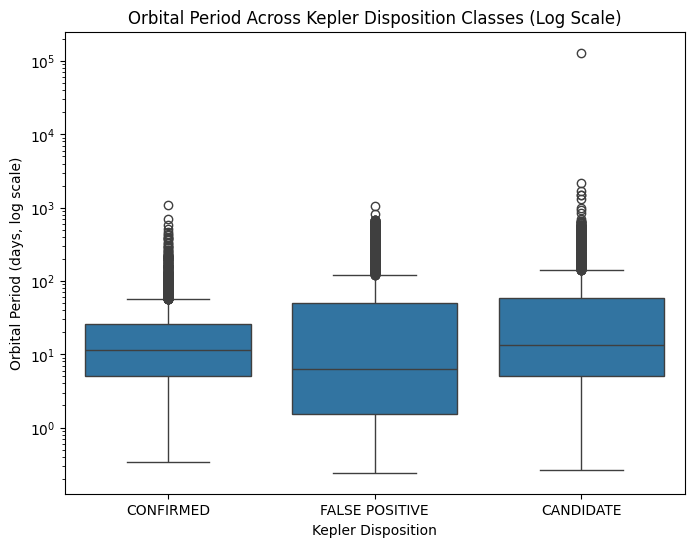

In [31]:
plt.figure(figsize=(8,6))
sns.boxplot(x="koi_disposition", y="koi_period", data=df)
plt.yscale("log")
plt.title("Orbital Period Across Kepler Disposition Classes (Log Scale)")
plt.xlabel("Kepler Disposition")
plt.ylabel("Orbital Period (days, log scale)")
plt.show()

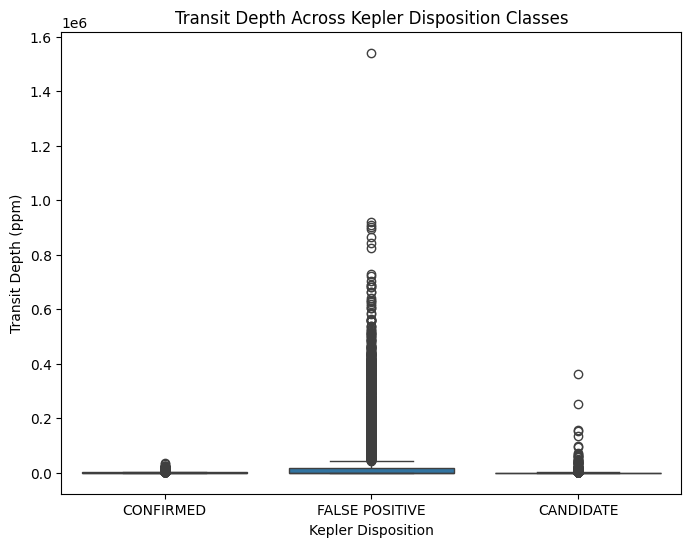

In [32]:
plt.figure(figsize=(8,6))
sns.boxplot(x="koi_disposition", y="koi_depth", data=df)
plt.title("Transit Depth Across Kepler Disposition Classes")
plt.xlabel("Kepler Disposition")
plt.ylabel("Transit Depth (ppm)")
plt.show()

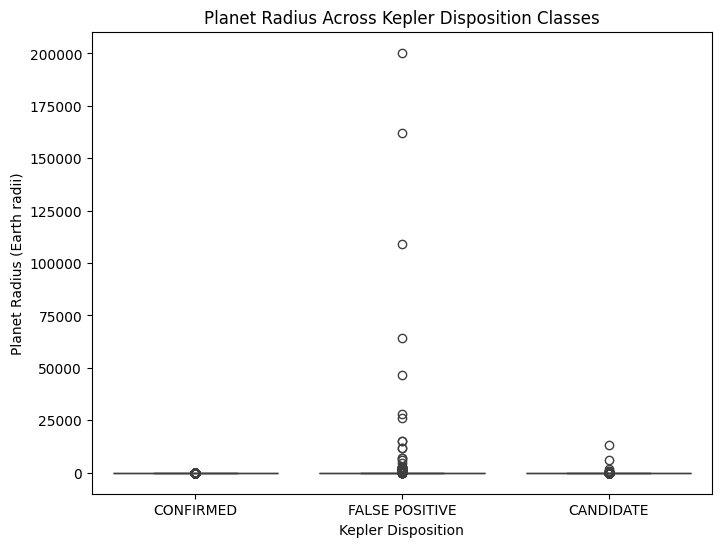

In [33]:
plt.figure(figsize=(8,6))
sns.boxplot(x="koi_disposition", y="koi_prad", data=df)
plt.title("Planet Radius Across Kepler Disposition Classes")
plt.xlabel("Kepler Disposition")
plt.ylabel("Planet Radius (Earth radii)")
plt.show()

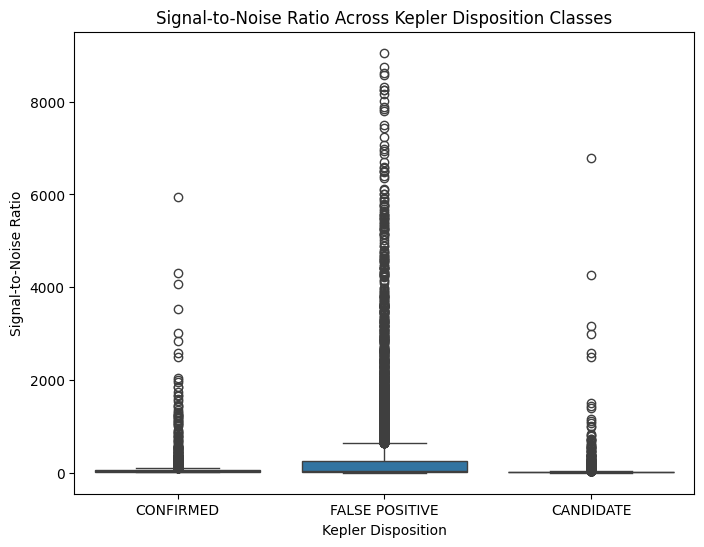

In [34]:
plt.figure(figsize=(8,6))
sns.boxplot(x="koi_disposition", y="koi_model_snr", data=df)
plt.title("Signal-to-Noise Ratio Across Kepler Disposition Classes")
plt.xlabel("Kepler Disposition")
plt.ylabel("Signal-to-Noise Ratio")
plt.show()

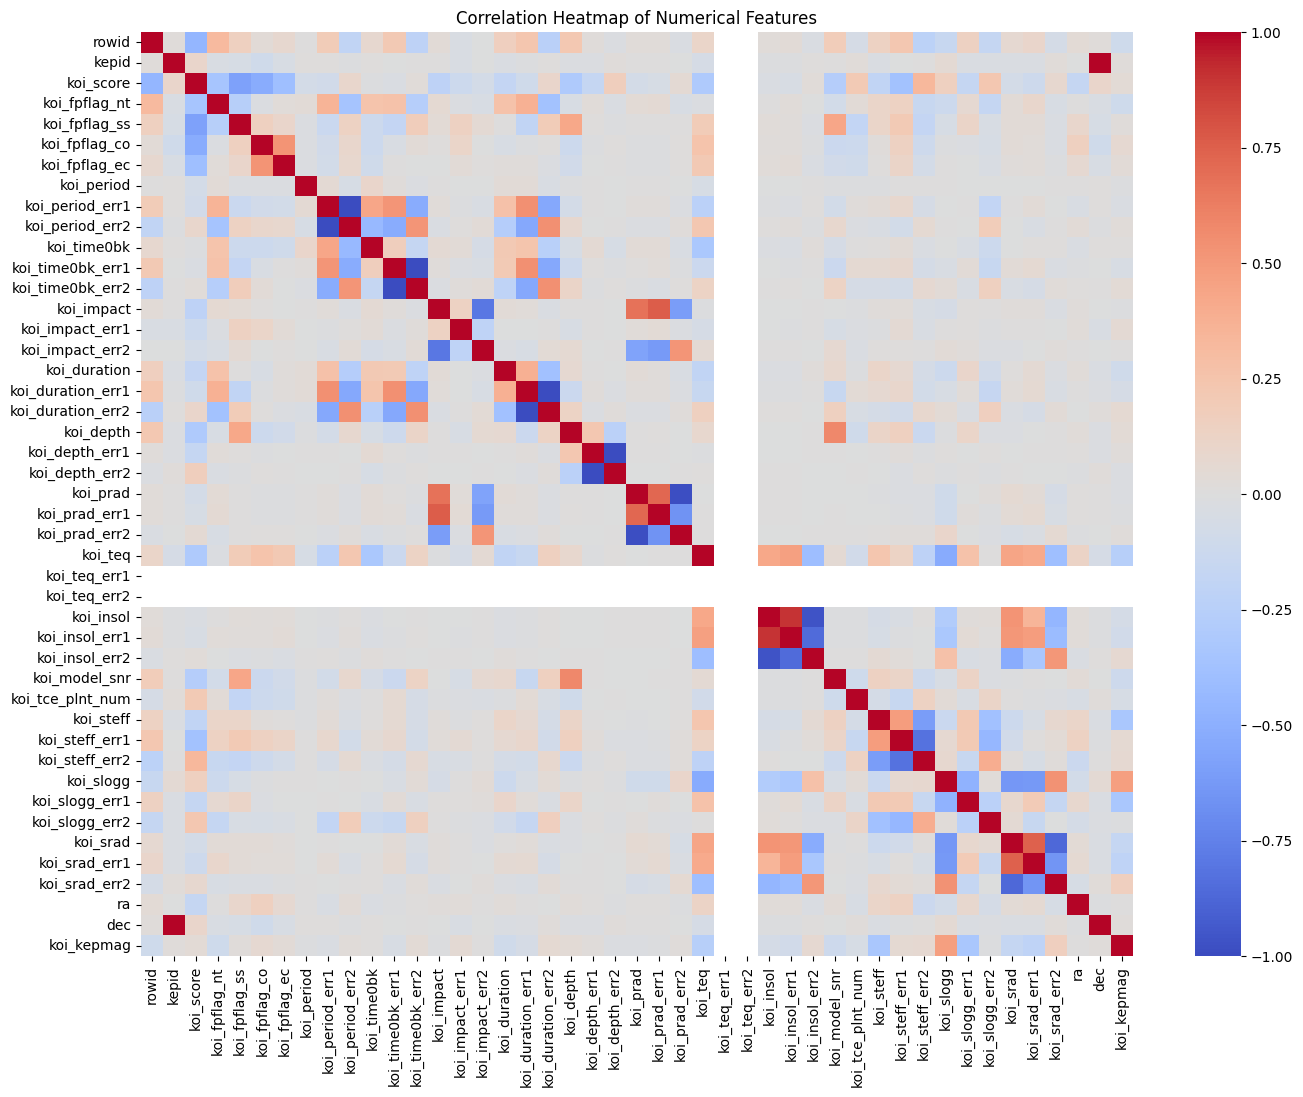

In [35]:
numeric_df = df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(16,12))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [36]:
leak_cols = [
    "rowid",
    "kepid",
    "kepoi_name",
    "kepler_name",
    "koi_pdisposition",
    "koi_score",
    "koi_tce_delivname",
    "koi_teq_err1",
    "koi_teq_err2",
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec"
]

star_ids = df["kepid"].copy()

df = df.drop(columns=leak_cols)
print(df.shape)

(9564, 37)


In [37]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (df.isnull().sum()/len(df))*100
})

missing_df = missing_df[missing_df["Missing Count"] > 0]
missing_df.sort_values("Missing Percent", ascending=False)

,Missing Count,Missing Percent
koi_steff_err2,483,5.050188
koi_srad_err2,468,4.893350
koi_slogg_err1,468,4.893350
koi_slogg_err2,468,4.893350
koi_srad_err1,468,4.893350
koi_steff_err1,468,4.893350
koi_period_err1,454,4.746968
koi_depth_err1,454,4.746968
koi_duration_err2,454,4.746968
koi_period_err2,454,4.746968


In [38]:
mapping = {
    "CONFIRMED": 0,
    "FALSE POSITIVE": 1,
    "CANDIDATE": 2
}

df["koi_disposition"] = df["koi_disposition"].map(mapping)

In [39]:
df["koi_disposition"].value_counts().sort_index()

koi_disposition
0    2293
1    5023
2    2248
Name: count, dtype: int64

In [40]:
X = df.drop(columns=["koi_disposition"])
y = df["koi_disposition"]
groups = star_ids

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

In [41]:
log_reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [42]:
y_pred_lr = log_reg_pipeline.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.6603575184016824


In [43]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
))

                precision    recall  f1-score   support

     CONFIRMED       0.63      0.86      0.73       443
FALSE POSITIVE       0.89      0.63      0.74      1021
     CANDIDATE       0.40      0.52      0.45       438

      accuracy                           0.66      1902
     macro avg       0.64      0.67      0.64      1902
  weighted avg       0.71      0.66      0.67      1902



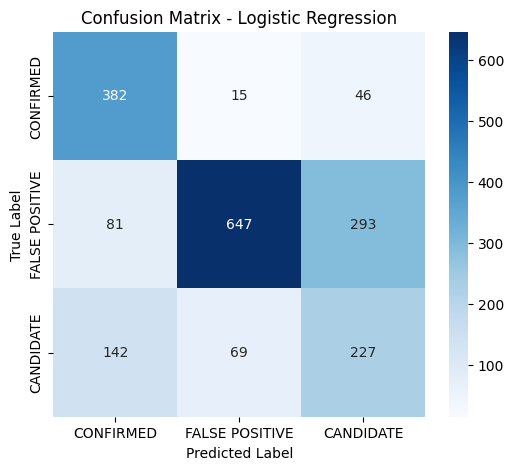

In [44]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"],
    yticklabels=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [45]:
dt_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", DecisionTreeClassifier(random_state=42, max_depth=10, class_weight="balanced"))
])

dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

In [46]:
y_pred_dt = dt_pipeline.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.6798107255520505


In [47]:
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
))

                precision    recall  f1-score   support

     CONFIRMED       0.69      0.80      0.74       443
FALSE POSITIVE       0.87      0.67      0.76      1021
     CANDIDATE       0.42      0.58      0.49       438

      accuracy                           0.68      1902
     macro avg       0.66      0.68      0.66      1902
  weighted avg       0.72      0.68      0.69      1902



In [48]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

In [49]:
y_pred_rf = rf_pipeline.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7802313354363828


In [50]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
))

                precision    recall  f1-score   support

     CONFIRMED       0.75      0.84      0.79       443
FALSE POSITIVE       0.83      0.90      0.86      1021
     CANDIDATE       0.65      0.45      0.53       438

      accuracy                           0.78      1902
     macro avg       0.74      0.73      0.73      1902
  weighted avg       0.77      0.78      0.77      1902



In [51]:
xgb_base_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.6, 0.8, 1.0],
    "classifier__colsample_bytree": [0.6, 0.8, 1.0]
}

group_cv = GroupKFold(n_splits=5)

xgb_search = RandomizedSearchCV(
    xgb_base_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="accuracy",
    cv=group_cv,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train, groups=groups_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...ass=3, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.6, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the 

In [52]:
print(xgb_search.best_params_)
xgb_pipeline = xgb_search.best_estimator_

{'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.6}


In [53]:
y_pred_xgb = xgb_pipeline.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.786540483701367


In [54]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
))

                precision    recall  f1-score   support

     CONFIRMED       0.76      0.86      0.81       443
FALSE POSITIVE       0.85      0.88      0.86      1021
     CANDIDATE       0.64      0.49      0.55       438

      accuracy                           0.79      1902
     macro avg       0.75      0.74      0.74      1902
  weighted avg       0.78      0.79      0.78      1902



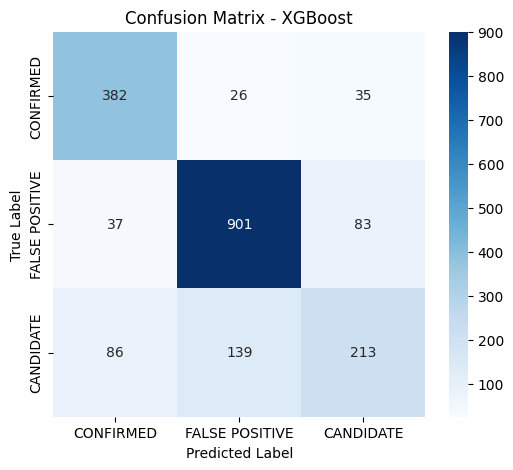

In [55]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"],
    yticklabels=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [56]:
cv_scores = {}

model_dict = {
    "Logistic Regression": log_reg_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

for name, model in model_dict.items():
    scores = cross_val_score(model, X_train, y_train, cv=group_cv, groups=groups_train, scoring="accuracy")
    cv_scores[name] = scores.mean()

In [57]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Test Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "CV Accuracy": [
        cv_scores["Logistic Regression"],
        cv_scores["Decision Tree"],
        cv_scores["Random Forest"],
        cv_scores["XGBoost"]
    ]
})

results = results.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

results["Rank"] = ["Best", "Runner-up", "3", "4"]

results = results[["Rank", "Model", "Test Accuracy", "CV Accuracy"]]
results

,Rank,Model,Test Accuracy,CV Accuracy
0,Best,XGBoost,0.786540,0.785434
1,Runner-up,Random Forest,0.780231,0.771991
2,3,Decision Tree,0.679811,0.703733
3,4,Logistic Regression,0.660358,0.679982


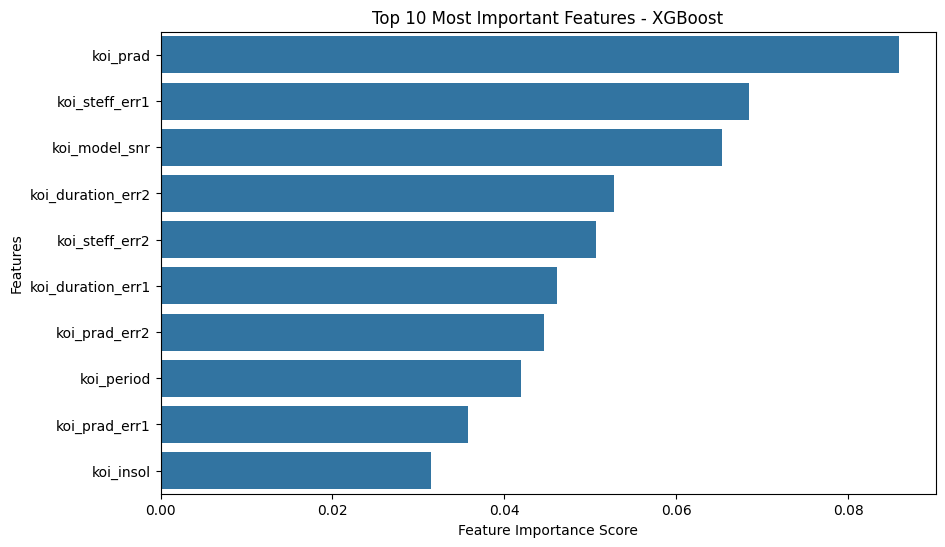

In [58]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_pipeline.named_steps["classifier"].feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features - XGBoost")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.show()

In [59]:
X_test_imputed = pd.DataFrame(
    xgb_pipeline.named_steps["imputer"].transform(X_test),
    columns=X_test.columns
)

explainer = shap.TreeExplainer(xgb_pipeline.named_steps["classifier"])

X_sample = X_test_imputed.sample(200, random_state=42)

shap_values = explainer.shap_values(X_sample)

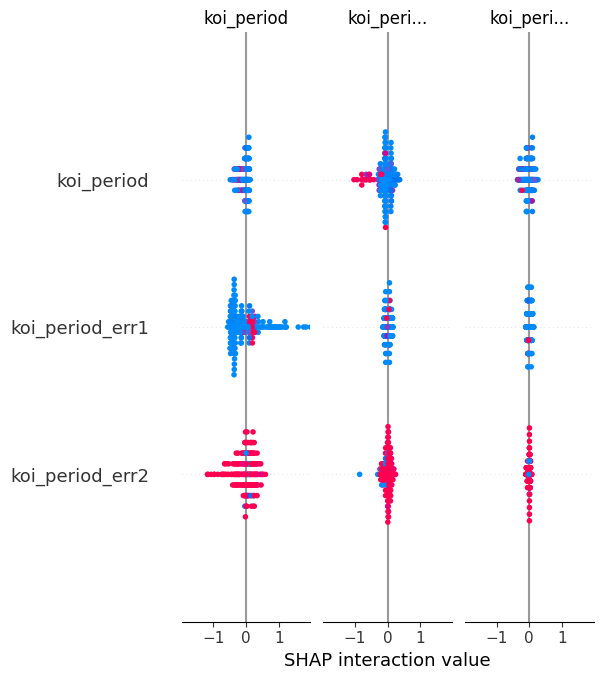

In [60]:
shap.summary_plot(
    shap_values,
    X_sample,
    class_names=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
)

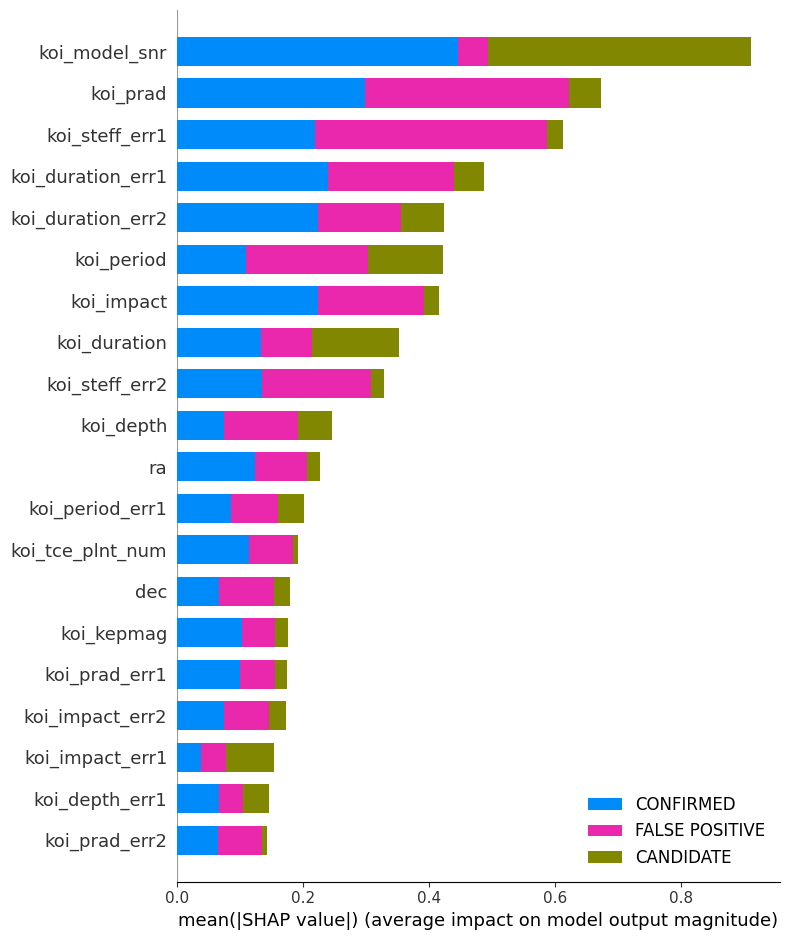

In [61]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    class_names=["CONFIRMED", "FALSE POSITIVE", "CANDIDATE"]
)

In [62]:
joblib.dump(xgb_pipeline, "kepler_xgboost_pipeline_v2.pkl")

['kepler_xgboost_pipeline_v2.pkl']